In [1]:
# Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model

In [ ]:
# Pull 20 years of SPY daily data
spy = yf.download("SPY", start="2004-01-01", end="2024-12-31", auto_adjust=True, progress=False)

# Keep only closing prices
prices = spy["Close"].dropna()

# Compute log returns
returns = np.log(prices / prices.shift(1)).dropna()

print(f"Date range:   {prices.index[0].date()} → {prices.index[-1].date()}")
print(f"Trading days: {len(prices)}")
print(f"Return stats:")
print(returns.describe().round(4))

Date range:   2004-01-02 → 2024-12-30
Trading days: 5284
Return stats:
Ticker        SPY
count   5283.0000
mean       0.0004
std        0.0118
min       -0.1159
25%       -0.0039
50%        0.0007
75%        0.0058
max        0.1356


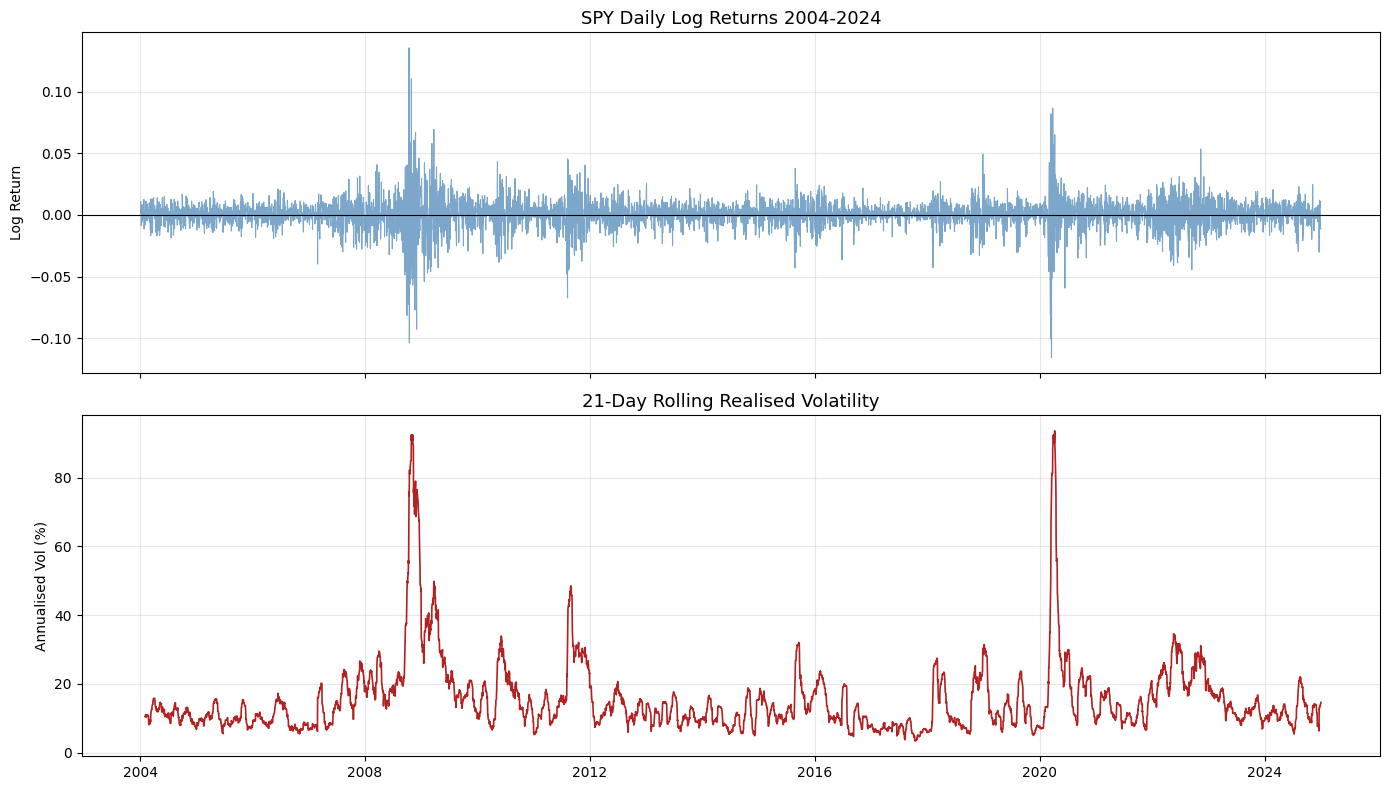

Rolling vol stats (annualised %):
Ticker      SPY
count   5263.00
mean      15.46
std       10.86
min        3.42
25%        9.25
50%       12.67
75%       18.10
max       93.67


In [4]:
# Rolling 21-day realised volatility (annualised)
rolling_vol = returns.rolling(window=21).std() * np.sqrt(252)

# Plot returns and rolling vol together
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(returns.index, returns, lw=0.8, color="steelblue", alpha=0.7)
ax1.axhline(0, color="black", lw=0.8)
ax1.set_ylabel("Log Return")
ax1.set_title("SPY Daily Log Returns 2004-2024", fontsize=13)
ax1.grid(alpha=0.3)

ax2.plot(rolling_vol.index, rolling_vol * 100, lw=1.2, color="firebrick")
ax2.set_ylabel("Annualised Vol (%)")
ax2.set_title("21-Day Rolling Realised Volatility", fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("returns_rolling_vol.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Rolling vol stats (annualised %):")
print((rolling_vol * 100).describe().round(2))

In [6]:
# GARCH(1,1) expects returns scaled to percentage — multiply by 100
returns_pct = returns * 100

# Fit GARCH(1,1) model
model = arch_model(returns_pct, vol="Garch", p=1, q=1, dist="normal")
result = model.fit(disp="off")   # disp="off" suppresses verbose output

print(result.summary())

omega    = 0.0283
alpha    = 0.1318
beta     = 0.8435

long_run_var     = omega / (1 - alpha - beta)
long_run_vol_pct = np.sqrt(long_run_var * 252)
print(f"Long-run annualised vol: {long_run_vol_pct:.2f}%")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6930.42
Distribution:                  Normal   AIC:                           13868.8
Method:            Maximum Likelihood   BIC:                           13895.1
                                        No. Observations:                 5283
Date:                Thu, Apr 16 2026   Df Residuals:                     5282
Time:                        17:19:25   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0751  1.053e-02      7.130  1.007e-12 [5.

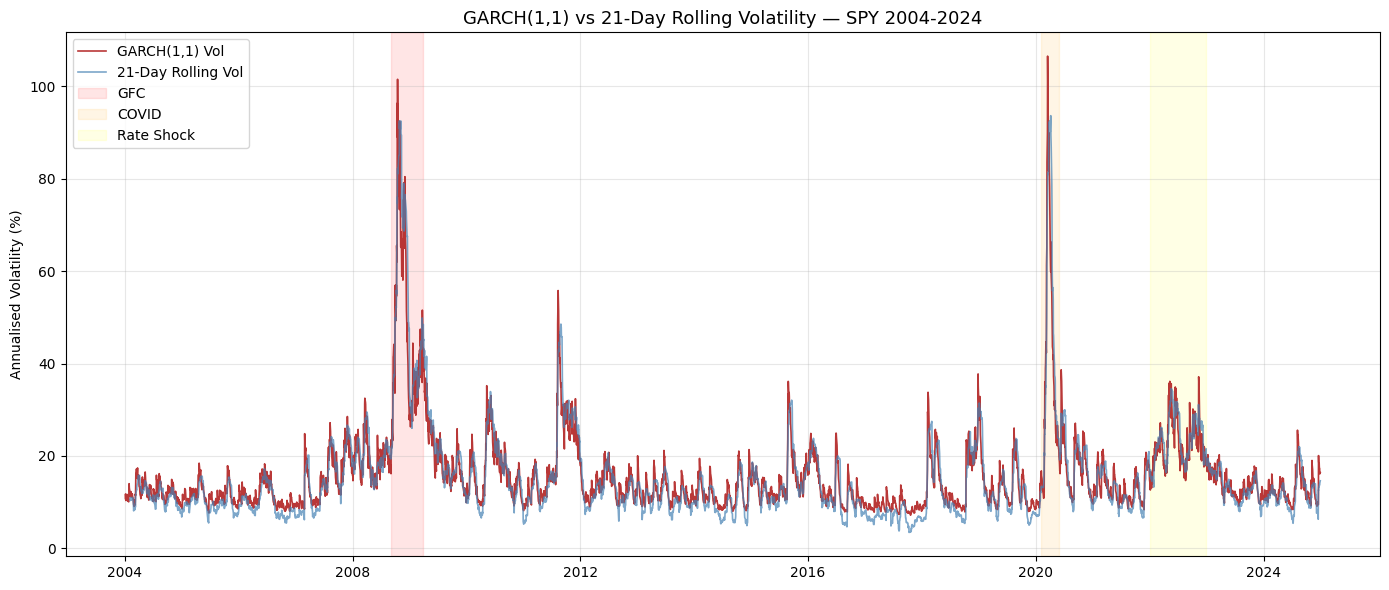

In [7]:
# Extract GARCH conditional volatility (annualised)
garch_vol = result.conditional_volatility * np.sqrt(252) / 100  # back to decimal

# Align rolling vol index with GARCH vol
rolling_vol_aligned = rolling_vol.reindex(garch_vol.index)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(garch_vol.index, garch_vol * 100, 
        lw=1.2, color="firebrick", label="GARCH(1,1) Vol", alpha=0.9)
ax.plot(rolling_vol_aligned.index, rolling_vol_aligned * 100, 
        lw=1.2, color="steelblue", label="21-Day Rolling Vol", alpha=0.7)

# Shade major stress regimes
ax.axvspan("2008-09-01", "2009-03-31", alpha=0.1, color="red", label="GFC")
ax.axvspan("2020-02-01", "2020-05-31", alpha=0.1, color="orange", label="COVID")
ax.axvspan("2022-01-01", "2022-12-31", alpha=0.1, color="yellow", label="Rate Shock")

ax.set_ylabel("Annualised Volatility (%)")
ax.set_title("GARCH(1,1) vs 21-Day Rolling Volatility — SPY 2004-2024", fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("garch_vs_rolling.png", dpi=150, bbox_inches="tight")
plt.show()